# 08 Benchmark: Delta vs Iceberg vs Hudi

This notebook compares three major open data lake table formats:

- Delta Lake
- Apache Iceberg
- Apache Hudi

The focus is not only simple read/write performance, but also production-relevant behavior such as upserts, file layout, small files, predicate pruning, and query plans.

In this notebook, you will benchmark:

- Initial table write performance
- Filtered read performance
- MERGE / UPSERT performance
- File count and small files behavior
- Predicate pruning using `explain(True)`
- Visual comparison with matplotlib charts

This notebook is designed for a local Spark 4.x Docker cluster with Delta, Iceberg, and Hudi JARs already available in `/opt/spark/jars`.

## Step 1 — Create Spark session

This notebook assumes the required JARs are already preloaded in the Docker image.

Do not use `spark.jars.packages` here, because it would trigger Maven/Ivy downloads from inside the notebook.

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("07-Benchmark-Delta-Iceberg-Hudi")
    .master("spark://spark-master:7077")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config(
        "spark.sql.extensions",
        "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions,"
        "io.delta.sql.DeltaSparkSessionExtension,"
        "org.apache.spark.sql.hudi.HoodieSparkSessionExtension"
    )
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    .config("spark.sql.catalog.local", "org.apache.iceberg.spark.SparkCatalog")
    .config("spark.sql.catalog.local.type", "hadoop")
    .config("spark.sql.catalog.local.warehouse", "/workspace/data/warehouse/iceberg")
    .getOrCreate()
)

print("Spark version:", spark.version)
print("Application ID:", spark.sparkContext.applicationId)

Spark version: 4.0.2
Application ID: app-20260425202422-0009


## Step 2 — Define benchmark paths and helper functions

The benchmark writes into `/workspace/data`, which should be shared between the notebook container and Spark workers.

In [2]:
import os
import shutil
import time
from pathlib import Path
from collections import defaultdict

BASE_PATH = "/workspace/data/benchmark/delta_iceberg_hudi"

DELTA_PATH = f"{BASE_PATH}/delta_bench"
HUDI_PATH = f"{BASE_PATH}/hudi_bench"
ICEBERG_NAMESPACE = "local.benchmark"
ICEBERG_TABLE = f"{ICEBERG_NAMESPACE}.iceberg_bench"

RESULTS = []

def timed(label, fmt, operation, fn):
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start

    RESULTS.append({
        "format": fmt,
        "operation": operation,
        "label": label,
        "seconds": elapsed,
    })

    print(f"{label}: {elapsed:.3f} sec")
    return result

def safe_rm(path):
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f"Removed: {path}")

def count_files(root_path):
    root = Path(root_path)
    if not root.exists():
        return {
            "total_files": 0,
            "parquet_files": 0,
            "metadata_files": 0,
            "total_bytes": 0,
            "small_parquet_files": 0,
            "parquet_bytes": 0,
        }

    total_files = 0
    parquet_files = 0
    metadata_files = 0
    total_bytes = 0
    parquet_bytes = 0
    small_parquet_files = 0
    small_file_threshold = 16 * 1024 * 1024

    for path in root.rglob("*"):
        if path.is_file():
            total_files += 1
            size = path.stat().st_size
            total_bytes += size

            if path.suffix == ".parquet":
                parquet_files += 1
                parquet_bytes += size
                if size < small_file_threshold:
                    small_parquet_files += 1

            if any(part.startswith(".") or part in ["metadata"] for part in path.parts):
                metadata_files += 1

    return {
        "total_files": total_files,
        "parquet_files": parquet_files,
        "metadata_files": metadata_files,
        "total_bytes": total_bytes,
        "small_parquet_files": small_parquet_files,
        "parquet_bytes": parquet_bytes,
    }

def bytes_to_mb(value):
    return round(value / 1024 / 1024, 2)

## Step 3 — Clean previous benchmark run

The notebook starts clean so repeated benchmark runs are easier to compare.

In [3]:
safe_rm(BASE_PATH)
safe_rm("/workspace/data/warehouse/iceberg/benchmark")

spark.sql("CREATE NAMESPACE IF NOT EXISTS local.benchmark")

try:
    spark.sql(f"DROP TABLE IF EXISTS {ICEBERG_TABLE}")
except Exception as exc:
    print("Iceberg drop warning:", exc)

print("Benchmark cleanup completed.")

Benchmark cleanup completed.


## Step 4 — Generate benchmark dataset

The dataset is intentionally moderate so it can run on a local Docker Spark cluster.

You can increase `N_ROWS` if your machine has enough memory and CPU.

In [4]:
from pyspark.sql.functions import col, expr, rand, concat, lit, to_timestamp

N_ROWS = 500_000
N_PARTITIONS = 16

base_df = (
    spark.range(0, N_ROWS, 1, N_PARTITIONS)
    .withColumn("rider_id", concat(lit("r"), col("id").cast("string")))
    .withColumn("city_id", (col("id") % 20).cast("int"))
    .withColumn("city", concat(lit("CITY_"), col("city_id").cast("string")))
    .withColumn("event_day", expr("date_add(date'2024-01-01', int(id % 10))"))
    .withColumn("rating", (rand(seed=42) * 5).cast("double"))
    .withColumn("amount", (rand(seed=99) * 100).cast("double"))
    .withColumn("ts", to_timestamp(expr("concat(cast(event_day as string), ' 10:00:00')")))
    .select("id", "rider_id", "city", "event_day", "rating", "amount", "ts")
)

base_df.cache()
print("Base row count:", base_df.count())
base_df.show(5, truncate=False)

Base row count: 500000
+---+--------+------+----------+------------------+-----------------+-------------------+
|id |rider_id|city  |event_day |rating            |amount           |ts                 |
+---+--------+------+----------+------------------+-----------------+-------------------+
|0  |r0      |CITY_0|2024-01-01|3.095946851126505 |72.59431928873651|2024-01-01 10:00:00|
|1  |r1      |CITY_1|2024-01-02|2.5480094212232407|19.12687317294607|2024-01-02 10:00:00|
|2  |r2      |CITY_2|2024-01-03|4.162629694435762 |30.1504013513196 |2024-01-03 10:00:00|
|3  |r3      |CITY_3|2024-01-04|1.316140452058618 |50.65814531112763|2024-01-04 10:00:00|
|4  |r4      |CITY_4|2024-01-05|3.351433848132068 |82.89820216391746|2024-01-05 10:00:00|
+---+--------+------+----------+------------------+-----------------+-------------------+
only showing top 5 rows


## Step 5 — Write Delta, Iceberg, and Hudi tables

All three tables use the same logical data and partition strategy.

- Delta: path-based table
- Iceberg: Hadoop catalog table
- Hudi: Copy-On-Write table with `id` as record key

In [5]:
timed(
    "Delta initial write",
    "Delta",
    "initial_write",
    lambda: (
        base_df.write
        .format("delta")
        .mode("overwrite")
        .partitionBy("city")
        .save(DELTA_PATH)
    )
)

timed(
    "Iceberg initial write",
    "Iceberg",
    "initial_write",
    lambda: (
        base_df.writeTo(ICEBERG_TABLE)
        .using("iceberg")
        .partitionedBy("city")
        .createOrReplace()
    )
)

hudi_options = {
    "hoodie.table.name": "hudi_bench",
    "hoodie.datasource.write.table.name": "hudi_bench",
    "hoodie.datasource.write.recordkey.field": "id",
    "hoodie.datasource.write.partitionpath.field": "city",
    "hoodie.datasource.write.precombine.field": "ts",
    "hoodie.datasource.write.table.type": "COPY_ON_WRITE",
    "hoodie.datasource.write.operation": "upsert",
    "hoodie.metadata.enable": "true",
}

timed(
    "Hudi initial write",
    "Hudi",
    "initial_write",
    lambda: (
        base_df.write
        .format("hudi")
        .options(**hudi_options)
        .mode("overwrite")
        .save(HUDI_PATH)
    )
)

Delta initial write: 9.137 sec


Iceberg initial write: 3.253 sec


# WARNING: Unable to get Instrumentation. Dynamic Attach failed. You may add this JAR as -javaagent manually, or supply -Djdk.attach.allowAttachSelf
# WARNING: Unable to attach Serviceability Agent. You can try again with escalated privileges. Two options: a) use -Djol.tryWithSudo=true to try with sudo; b) echo 0 | sudo tee /proc/sys/kernel/yama/ptrace_scope


[Stage 42:>                                                        (0 + 4) / 20]

26/04/25 20:25:13 WARN HoodieTableFileSystemView: Partition: CITY_5 is not available in store
26/04/25 20:25:13 WARN HoodieTableFileSystemView: Partition: CITY_4 is not available in store
26/04/25 20:25:13 WARN HoodieTableFileSystemView: Partition: CITY_19 is not available in store
26/04/25 20:25:13 WARN HoodieTableFileSystemView: Partition: CITY_6 is not available in store
26/04/25 20:25:15 WARN HoodieTableFileSystemView: Partition: CITY_8 is not available in store
26/04/25 20:25:15 WARN HoodieTableFileSystemView: Partition: CITY_15 is not available in store
26/04/25 20:25:15 WARN HoodieTableFileSystemView: Partition: CITY_7 is not available in store
26/04/25 20:25:15 WARN HoodieTableFileSystemView: Partition: CITY_16 is not available in store


...

[Stage 42:=================================>                      (12 + 4) / 20]

26/04/25 20:25:16 WARN HoodieTableFileSystemView: Partition: CITY_13 is not available in store
26/04/25 20:25:16 WARN HoodieTableFileSystemView: Partition: CITY_12 is not available in store
26/04/25 20:25:16 WARN HoodieTableFileSystemView: Partition: CITY_14 is not available in store
26/04/25 20:25:16 WARN HoodieTableFileSystemView: Partition: CITY_10 is not available in store


[Stage 42:============================================>           (16 + 4) / 20]

26/04/25 20:25:16 WARN HoodieTableFileSystemView: Partition: CITY_1 is not available in store
26/04/25 20:25:16 WARN HoodieTableFileSystemView: Partition: CITY_0 is not available in store
26/04/25 20:25:16 WARN HoodieTableFileSystemView: Partition: CITY_2 is not available in store
26/04/25 20:25:16 WARN HoodieTableFileSystemView: Partition: CITY_3 is not available in store


Hudi initial write: 38.801 sec


## Step 6 — Register views/tables for querying

For Delta and Hudi we register temporary views from paths. Iceberg is already a catalog table.

In [6]:
spark.read.format("delta").load(DELTA_PATH).createOrReplaceTempView("delta_bench")
spark.read.format("hudi").load(HUDI_PATH).createOrReplaceTempView("hudi_bench")

print("Delta count:", spark.sql("SELECT count(*) FROM delta_bench").collect()[0][0])
print("Iceberg count:", spark.sql(f"SELECT count(*) FROM {ICEBERG_TABLE}").collect()[0][0])
print("Hudi count:", spark.sql("SELECT count(*) FROM hudi_bench").collect()[0][0])

26/04/25 20:25:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Delta count: 500000
Iceberg count: 500000
Hudi count: 500000


## Step 7 — Filtered read benchmark

This benchmark uses a partition predicate (`city = 'CITY_5'`) and a regular column predicate.

The goal is to compare practical query performance, not just full table scans.

In [7]:
FILTER_CITY = "CITY_5"

timed(
    "Delta filtered read",
    "Delta",
    "filtered_read",
    lambda: spark.sql(f'''
        SELECT count(*), avg(amount)
        FROM delta_bench
        WHERE city = '{FILTER_CITY}' AND rating > 2.5
    ''').collect()
)

timed(
    "Iceberg filtered read",
    "Iceberg",
    "filtered_read",
    lambda: spark.sql(f'''
        SELECT count(*), avg(amount)
        FROM {ICEBERG_TABLE}
        WHERE city = '{FILTER_CITY}' AND rating > 2.5
    ''').collect()
)

timed(
    "Hudi filtered read",
    "Hudi",
    "filtered_read",
    lambda: spark.sql(f'''
        SELECT count(*), avg(amount)
        FROM hudi_bench
        WHERE city = '{FILTER_CITY}' AND rating > 2.5
    ''').collect()
)

Delta filtered read: 1.027 sec
Iceberg filtered read: 0.632 sec
Hudi filtered read: 1.560 sec


[Row(count(1)=12502, avg(amount)=50.26705379663416)]

## Step 8 — Prepare UPSERT / MERGE dataset

This dataset updates existing records and inserts new records.

- Existing ids: update path
- New ids: insert path

Hudi is designed around efficient upserts, so this benchmark is important.

In [8]:
from pyspark.sql.functions import when

UPDATE_ROWS = 50_000
INSERT_ROWS = 10_000

updates_df = (
    spark.range(0, UPDATE_ROWS, 1, 8)
    .withColumn("id", col("id").cast("long"))
    .withColumn("rider_id", concat(lit("r"), col("id").cast("string")))
    .withColumn("city_id", (col("id") % 20).cast("int"))
    .withColumn("city", concat(lit("CITY_"), col("city_id").cast("string")))
    .withColumn("event_day", expr("date'2024-01-15'"))
    .withColumn("rating", lit(4.95).cast("double"))
    .withColumn("amount", lit(999.0).cast("double"))
    .withColumn("ts", to_timestamp(lit("2024-01-15 12:00:00")))
    .select("id", "rider_id", "city", "event_day", "rating", "amount", "ts")
)

inserts_df = (
    spark.range(N_ROWS, N_ROWS + INSERT_ROWS, 1, 4)
    .withColumn("id", col("id").cast("long"))
    .withColumn("rider_id", concat(lit("r"), col("id").cast("string")))
    .withColumn("city_id", (col("id") % 20).cast("int"))
    .withColumn("city", concat(lit("CITY_"), col("city_id").cast("string")))
    .withColumn("event_day", expr("date'2024-01-15'"))
    .withColumn("rating", lit(3.75).cast("double"))
    .withColumn("amount", lit(111.0).cast("double"))
    .withColumn("ts", to_timestamp(lit("2024-01-15 12:30:00")))
    .select("id", "rider_id", "city", "event_day", "rating", "amount", "ts")
)

upsert_df = updates_df.unionByName(inserts_df)
upsert_df.cache()

print("Upsert row count:", upsert_df.count())
upsert_df.show(5, truncate=False)

Upsert row count: 60000
+---+--------+------+----------+------+------+-------------------+
|id |rider_id|city  |event_day |rating|amount|ts                 |
+---+--------+------+----------+------+------+-------------------+
|0  |r0      |CITY_0|2024-01-15|4.95  |999.0 |2024-01-15 12:00:00|
|1  |r1      |CITY_1|2024-01-15|4.95  |999.0 |2024-01-15 12:00:00|
|2  |r2      |CITY_2|2024-01-15|4.95  |999.0 |2024-01-15 12:00:00|
|3  |r3      |CITY_3|2024-01-15|4.95  |999.0 |2024-01-15 12:00:00|
|4  |r4      |CITY_4|2024-01-15|4.95  |999.0 |2024-01-15 12:00:00|
+---+--------+------+----------+------+------+-------------------+
only showing top 5 rows


## Step 9 — Delta MERGE benchmark

Delta Lake uses `MERGE INTO` for upserts.

In [9]:
from delta.tables import DeltaTable

upsert_df.createOrReplaceTempView("upsert_source")

def delta_merge():
    delta_table = DeltaTable.forPath(spark, DELTA_PATH)

    (
        delta_table.alias("t")
        .merge(upsert_df.alias("s"), "t.id = s.id")
        .whenMatchedUpdateAll()
        .whenNotMatchedInsertAll()
        .execute()
    )

timed("Delta MERGE", "Delta", "merge_upsert", delta_merge)

spark.read.format("delta").load(DELTA_PATH).createOrReplaceTempView("delta_bench")
print("Delta count after MERGE:", spark.sql("SELECT count(*) FROM delta_bench").collect()[0][0])

26/04/25 20:25:42 WARN MapPartitionsRDD: RDD 239 was locally checkpointed, its lineage has been truncated and cannot be recomputed after unpersisting
Delta MERGE: 11.437 sec


[Stage 106:==================================================>    (46 + 4) / 50]

Delta count after MERGE: 510000


## Step 10 — Iceberg MERGE benchmark

Iceberg supports SQL `MERGE INTO` through Spark extensions.

The source is a temporary view created from the same upsert dataset.

In [10]:
def iceberg_merge():
    spark.sql(f'''
        MERGE INTO {ICEBERG_TABLE} t
        USING upsert_source s
        ON t.id = s.id
        WHEN MATCHED THEN UPDATE SET
            rider_id = s.rider_id,
            city = s.city,
            event_day = s.event_day,
            rating = s.rating,
            amount = s.amount,
            ts = s.ts
        WHEN NOT MATCHED THEN INSERT *
    ''')

timed("Iceberg MERGE", "Iceberg", "merge_upsert", iceberg_merge)

print("Iceberg count after MERGE:", spark.sql(f"SELECT count(*) FROM {ICEBERG_TABLE}").collect()[0][0])

Iceberg MERGE: 3.689 sec
Iceberg count after MERGE: 510000


## Step 11 — Hudi UPSERT benchmark

Hudi performs upserts natively through the DataSource writer.

This is the workload where Hudi is often strongest: record-key based updates and inserts.

In [11]:
def hudi_upsert():
    (
        upsert_df.write
        .format("hudi")
        .options(**hudi_options)
        .mode("append")
        .save(HUDI_PATH)
    )

timed("Hudi UPSERT", "Hudi", "merge_upsert", hudi_upsert)

spark.read.format("hudi").load(HUDI_PATH).createOrReplaceTempView("hudi_bench")
print("Hudi count after UPSERT:", spark.sql("SELECT count(*) FROM hudi_bench").collect()[0][0])

Hudi UPSERT: 24.338 sec
Hudi count after UPSERT: 510000


## Step 12 — Validate updated records

All formats should now contain:

- updated records for ids in `[0, UPDATE_ROWS)`
- inserted records for ids in `[N_ROWS, N_ROWS + INSERT_ROWS)`

In [12]:
validation_queries = {
    "Delta": "delta_bench",
    "Iceberg": ICEBERG_TABLE,
    "Hudi": "hudi_bench",
}

for fmt, table in validation_queries.items():
    result = spark.sql(f'''
        SELECT
            count(*) AS total_rows,
            sum(CASE WHEN amount = 999.0 THEN 1 ELSE 0 END) AS updated_rows,
            sum(CASE WHEN id >= {N_ROWS} THEN 1 ELSE 0 END) AS inserted_rows
        FROM {table}
    ''').collect()[0]

    print(fmt, dict(result.asDict()))

Delta {'total_rows': 510000, 'updated_rows': 50000, 'inserted_rows': 10000}
Iceberg {'total_rows': 510000, 'updated_rows': 50000, 'inserted_rows': 10000}
Hudi {'total_rows': 510000, 'updated_rows': 50000, 'inserted_rows': 10000}


## Step 13 — File count and small files analysis

This section compares physical file layout after the initial write and upsert/merge operations.

Small files are a major performance concern in data lake tables.

In [13]:
# Iceberg Hadoop catalog table data lives under the configured warehouse.
ICEBERG_PATH = "/workspace/data/warehouse/iceberg/benchmark/iceberg_bench"

file_stats = []

for fmt, path in [
    ("Delta", DELTA_PATH),
    ("Iceberg", ICEBERG_PATH),
    ("Hudi", HUDI_PATH),
]:
    stats = count_files(path)
    stats["format"] = fmt
    stats["total_mb"] = bytes_to_mb(stats["total_bytes"])
    stats["parquet_mb"] = bytes_to_mb(stats["parquet_bytes"])
    file_stats.append(stats)

file_stats

[{'total_files': 688,
  'parquet_files': 340,
  'metadata_files': 344,
  'total_bytes': 14124796,
  'small_parquet_files': 340,
  'parquet_bytes': 13764968,
  'format': 'Delta',
  'total_mb': 13.47,
  'parquet_mb': 13.13},
 {'total_files': 96,
  'parquet_files': 40,
  'metadata_files': 56,
  'total_bytes': 17667135,
  'small_parquet_files': 40,
  'parquet_bytes': 17487850,
  'format': 'Iceberg',
  'total_mb': 16.85,
  'parquet_mb': 16.68},
 {'total_files': 200,
  'parquet_files': 40,
  'metadata_files': 160,
  'total_bytes': 44407786,
  'small_parquet_files': 40,
  'parquet_bytes': 43807299,
  'format': 'Hudi',
  'total_mb': 42.35,
  'parquet_mb': 41.78}]

In [14]:
import pandas as pd

file_stats_df = pd.DataFrame(file_stats)
file_stats_df = file_stats_df[
    [
        "format",
        "total_files",
        "parquet_files",
        "metadata_files",
        "small_parquet_files",
        "total_mb",
        "parquet_mb",
    ]
]

file_stats_df

,format,total_files,parquet_files,metadata_files,small_parquet_files,total_mb,parquet_mb
0,Delta,688,340,344,340,13.47,13.13
1,Iceberg,96,40,56,40,16.85,16.68
2,Hudi,200,40,160,40,42.35,41.78


## Step 14 — Explain plan comparison

We inspect the query plan for the same partition-filtered query across all three formats.

Look for:

- Partition filters
- Pushed filters
- File scan strategy
- Data source relation

In [15]:
print("Delta EXPLAIN")
spark.sql(f'''
SELECT rider_id, amount
FROM delta_bench
WHERE city = '{FILTER_CITY}' AND amount > 50
''').explain(True)

print("\nIceberg EXPLAIN")
spark.sql(f'''
SELECT rider_id, amount
FROM {ICEBERG_TABLE}
WHERE city = '{FILTER_CITY}' AND amount > 50
''').explain(True)

print("\nHudi EXPLAIN")
spark.sql(f'''
SELECT rider_id, amount
FROM hudi_bench
WHERE city = '{FILTER_CITY}' AND amount > 50
''').explain(True)

Delta EXPLAIN
== Parsed Logical Plan ==
'Project ['rider_id, 'amount]
+- 'Filter (('city = CITY_5) AND ('amount > 50))
   +- 'UnresolvedRelation [delta_bench], [], false

== Analyzed Logical Plan ==
rider_id: string, amount: double
Project [rider_id#2631, amount#2635]
+- Filter ((city#2632 = CITY_5) AND (amount#2635 > cast(50 as double)))
   +- SubqueryAlias delta_bench
      +- View (`delta_bench`, [id#2630L, rider_id#2631, city#2632, event_day#2633, rating#2634, amount#2635, ts#2636])
         +- Relation [id#2630L,rider_id#2631,city#2632,event_day#2633,rating#2634,amount#2635,ts#2636] parquet

== Optimized Logical Plan ==
Project [rider_id#2631, amount#2635]
+- Filter ((isnotnull(city#2632) AND isnotnull(amount#2635)) AND ((city#2632 = CITY_5) AND (amount#2635 > 50.0)))
   +- Relation [id#2630L,rider_id#2631,city#2632,event_day#2633,rating#2634,amount#2635,ts#2636] parquet

== Physical Plan ==
*(1) Project [rider_id#2631, amount#2635]
+- *(1) Filter (isnotnull(amount#2635) AND (amou

## Step 15 — Collect benchmark results into a table

The timing table is used for the charts in the next step.

In [16]:
results_df = pd.DataFrame(RESULTS)
results_df = results_df.sort_values(["operation", "format"]).reset_index(drop=True)
results_df

,format,operation,label,seconds
0,Delta,filtered_read,Delta filtered read,1.026853
1,Hudi,filtered_read,Hudi filtered read,1.559773
2,Iceberg,filtered_read,Iceberg filtered read,0.632498
3,Delta,initial_write,Delta initial write,9.136566
4,Hudi,initial_write,Hudi initial write,38.800555
5,Iceberg,initial_write,Iceberg initial write,3.252629
6,Delta,merge_upsert,Delta MERGE,11.437479
7,Hudi,merge_upsert,Hudi UPSERT,24.338013
8,Iceberg,merge_upsert,Iceberg MERGE,3.688555


## Step 16 — Chart: operation runtime

The chart compares runtime by operation and table format.

Lower is better.

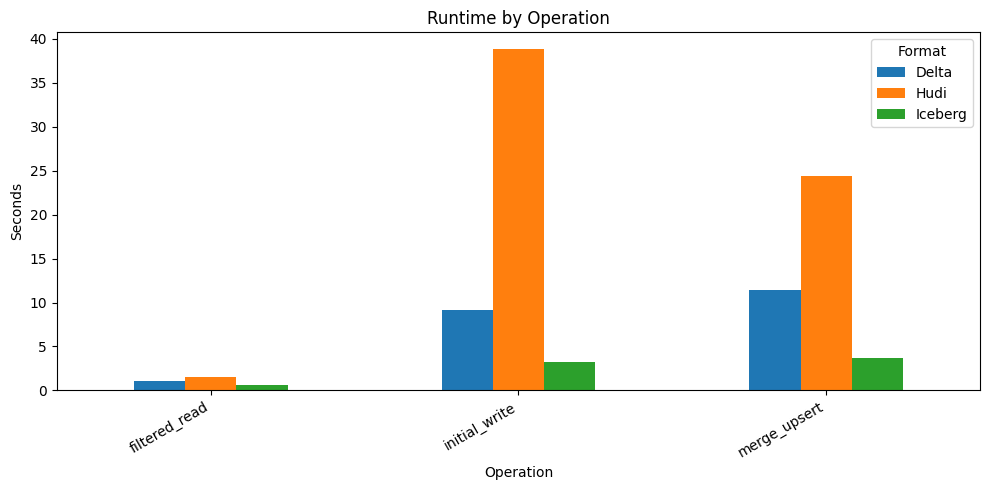

In [17]:
import matplotlib.pyplot as plt

pivot_runtime = results_df.pivot_table(
    index="operation",
    columns="format",
    values="seconds",
    aggfunc="mean"
)

ax = pivot_runtime.plot(kind="bar", figsize=(10, 5))
ax.set_title("Runtime by Operation")
ax.set_xlabel("Operation")
ax.set_ylabel("Seconds")
ax.legend(title="Format")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Step 17 — Chart: file count comparison

This chart compares total files and Parquet data files.

Lower file count is not always better, but too many small files can hurt query performance.

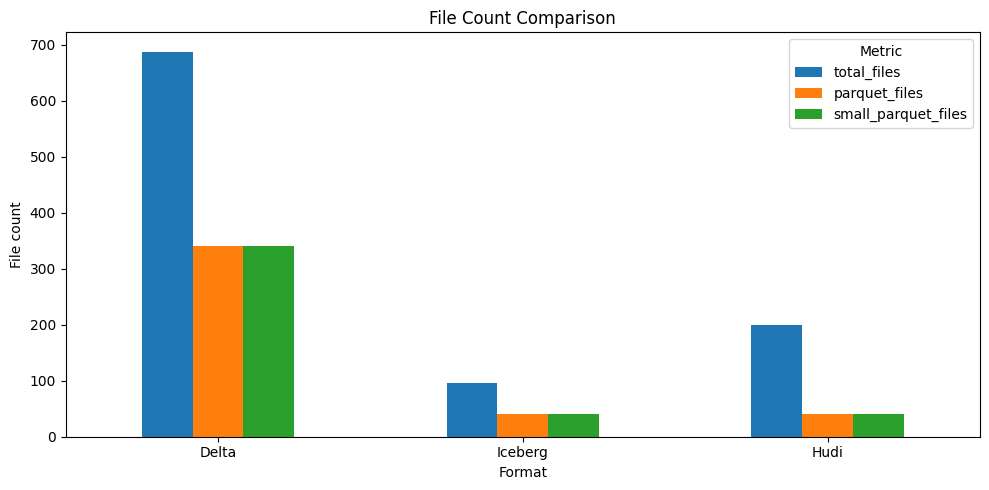

In [18]:
file_count_plot_df = file_stats_df.set_index("format")[["total_files", "parquet_files", "small_parquet_files"]]

ax = file_count_plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("File Count Comparison")
ax.set_xlabel("Format")
ax.set_ylabel("File count")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 18 — Chart: storage size comparison

This chart compares total table size and Parquet data size.

Metadata overhead differs between table formats, so both values are useful.

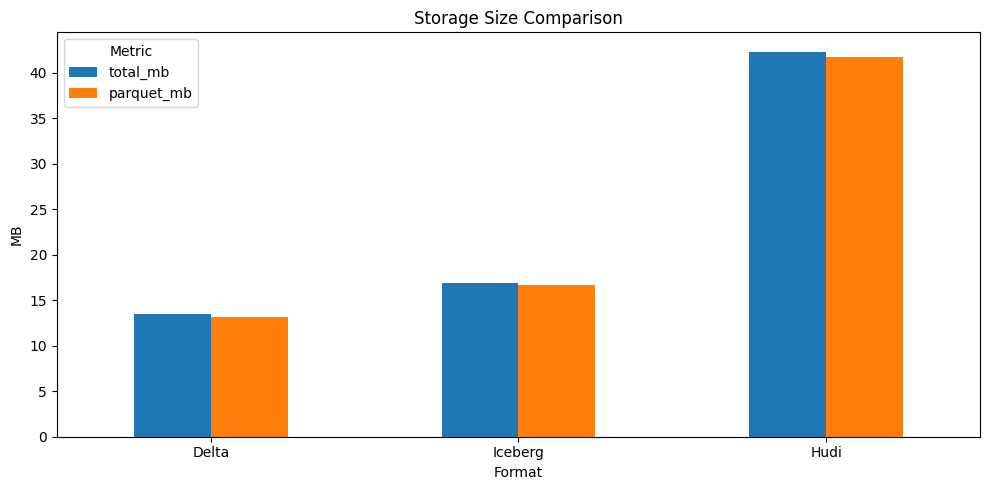

In [19]:
size_plot_df = file_stats_df.set_index("format")[["total_mb", "parquet_mb"]]

ax = size_plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Storage Size Comparison")
ax.set_xlabel("Format")
ax.set_ylabel("MB")
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 19 — Practical interpretation

Typical high-level interpretation:

- Delta Lake is often strong for general Spark SQL workloads and simple write/read operations.
- Apache Iceberg is excellent for table metadata, partition evolution, hidden partitioning, and multi-engine interoperability.
- Apache Hudi is designed around record-level upserts, incremental processing, and CDC-style pipelines.

Do not treat this local benchmark as a universal ranking. Production results depend on:

- data size
- partition design
- file size distribution
- cluster size
- object storage behavior
- table maintenance
- workload type

## Step 20 — Optional cleanup

Uncomment and run this cell if you want to delete benchmark output.

In [20]:
# safe_rm(BASE_PATH)
# safe_rm("/workspace/data/warehouse/iceberg/benchmark")
# spark.sql(f"DROP TABLE IF EXISTS {ICEBERG_TABLE}")